# 2_1 Análise de Dados

Realiza a **análise estatística e linguística** do corpus de notícias brasileiras.

> **Funciona com ou sem Google Drive.**

In [ ]:
import time
inicio_processamento = time.time()
print('Início registrado.')

Início registrado.


## 2 Carregamento do Corpus

In [ ]:
import sys, os, re, time, logging
import pandas as pd
from collections import Counter

logging.basicConfig(format="%(asctime)s : %(levelname)s : %(message)s")
logger = logging.getLogger(); logger.setLevel(logging.INFO)

# Detecta se está no Google Colab
IN_COLAB = "google.colab" in sys.modules

DIRETORIO_NOTEBOOK = "SRI"
NOME_ARQUIVO = "documentos.csv"

if IN_COLAB:
    # Tenta carregar do Google Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DIRETORIO_DRIVE = "/content/drive/MyDrive/Colab Notebooks/" + DIRETORIO_NOTEBOOK + "/data/"
        DIRETORIO_LOCAL = "/content/" + DIRETORIO_NOTEBOOK + "/"
        os.makedirs(DIRETORIO_LOCAL, exist_ok=True)
        import shutil
        shutil.copy(DIRETORIO_DRIVE + NOME_ARQUIVO, DIRETORIO_LOCAL + NOME_ARQUIVO)
        logging.info("Arquivo carregado do Google Drive.")
    except Exception:
        # Se não tiver Drive, usa corpus embutido
        logging.info("Drive não disponível. Usando corpus embutido.")
        DIRETORIO_LOCAL = "/content/" + DIRETORIO_NOTEBOOK + "/"
        os.makedirs(DIRETORIO_LOCAL, exist_ok=True)
else:
    DIRETORIO_LOCAL = "./data/"
    os.makedirs(DIRETORIO_LOCAL, exist_ok=True)

# Corpus embutido (fallback)
_documentos = [
    "O presidente Luiz Inácio Lula da Silva assinou hoje em Brasília um pacote de medidas para estimular a economia brasileira, incluindo investimentos em infraestrutura e geração de empregos.",
    "O Banco Central do Brasil decidiu manter a taxa Selic em 10,5% ao ano, segundo comunicado divulgado pelo Comitê de Política Monetária nesta quarta-feira.",
    "A Petrobras anunciou lucro líquido de R$ 23 bilhões no primeiro trimestre deste ano, superando as expectativas dos analistas de mercado.",
    "O ministro da Fazenda, Fernando Haddad, apresentou ao Congresso Nacional o novo arcabouço fiscal, que prevê meta de déficit zero para 2025.",
    "A Bolsa de Valores de São Paulo, a B3, registrou alta de 1,2% nesta sexta-feira, impulsionada pelo desempenho positivo das ações do setor bancário.",
    "O governador de São Paulo, Tarcísio de Freitas, anunciou a privatização de mais quatro empresas estatais do estado nos próximos dois anos.",
    "O Instituto Brasileiro de Geografia e Estatística divulgou que a taxa de desemprego caiu para 7,8% no segundo trimestre, menor nível desde 2014.",
    "A Vale informou que a produção de minério de ferro atingiu recorde histórico no terceiro trimestre, com 89,4 milhões de toneladas métricas.",
    "O Supremo Tribunal Federal concluiu o julgamento sobre a constitucionalidade da reforma tributária aprovada pelo Congresso Nacional.",
    "O presidente do Banco Central, Roberto Campos Neto, alertou sobre os riscos fiscais que podem comprometer a estabilidade da moeda nacional.",
    "A empresa de tecnologia Totvs anunciou a aquisição de uma startup de inteligência artificial por R$ 450 milhões no Rio de Janeiro.",
    "O Senado Federal aprovou por 52 votos a 19 a proposta de emenda constitucional que modifica as regras do sistema previdenciário.",
    "A Embraer fechou contrato de US$ 2 bilhões com companhia aérea americana para fornecimento de aeronaves E2 nos próximos cinco anos.",
    "O ministro da Educação anunciou a expansão do programa Bolsa Família para famílias com crianças em idade escolar em todo o território nacional.",
    "A Agência Nacional de Vigilância Sanitária aprovou novos medicamentos genéricos para o tratamento de doenças crônicas no Brasil.",
    "O prefeito de São Paulo, Ricardo Nunes, inaugurou o trecho norte da Linha 6 do metrô, que liga a estação Brasilândia ao centro da cidade.",
    "O Brasil registrou superávit comercial de US$ 8,4 bilhões em setembro, impulsionado pelas exportações de soja e petróleo.",
    "A Câmara dos Deputados aprovou em primeiro turno a reforma administrativa, que altera as regras do serviço público federal.",
    "O Conselho Nacional de Justiça publicou resolução que moderniza o sistema de processos digitais no Judiciário brasileiro.",
    "A Ambev divulgou crescimento de 15% nas vendas no mercado brasileiro, atribuído ao aumento do consumo nas regiões Norte e Nordeste.",
    "O governo federal lançou o programa Minha Casa Minha Vida ampliado, com meta de construir 2 milhões de habitações até 2026.",
    "A Agência Nacional de Telecomunicações anunciou o leilão de frequências 5G para as cidades de médio porte do interior do Brasil.",
    "O Tribunal de Contas da União apontou irregularidades em contratos de obras do Departamento Nacional de Infraestrutura de Transportes.",
    "A Sabesp, empresa de saneamento de São Paulo, informou que atingiu a meta de universalização do tratamento de esgoto no estado.",
    "O presidente da Câmara, Arthur Lira, pautou para votação o projeto de lei sobre a tributação de plataformas digitais internacionais.",
    "O Brasil sediará a Conferência das Nações Unidas sobre Mudanças Climáticas, a COP30, na cidade de Belém do Pará em novembro de 2025.",
    "A Fiocruz anunciou o desenvolvimento de nova vacina contra a dengue em parceria com universidades federais do Rio de Janeiro e São Paulo.",
    "O Ministério do Trabalho publicou portaria que estabelece novas regras para o teletrabalho e o trabalho híbrido no setor privado.",
    "A Receita Federal do Brasil arrecadou R$ 218 bilhões em agosto, recorde histórico para o mês, superando a previsão do governo federal.",
    "O Banco Nacional de Desenvolvimento Econômico e Social aprovou financiamento de R$ 12 bilhões para projetos de energia renovável no Nordeste.",
    "A ministra do Meio Ambiente, Marina Silva, assinou decreto que amplia em 2 milhões de hectares a área de proteção ambiental na Amazônia.",
    "O Instituto Nacional do Seguro Social informou que o pagamento do 13º salário dos aposentados será antecipado para o mês de agosto.",
]

# Salva o CSV localmente se não existir
csv_path = DIRETORIO_LOCAL + NOME_ARQUIVO
if not os.path.exists(csv_path):
    with open(csv_path, "w", encoding="utf-8") as f:
        f.write("id;texto\n")
        for i, doc in enumerate(_documentos, 1):
            f.write(f'{i};"{doc}"\n')

# Lê o CSV
NOME_ARQUIVO_DATASET = NOME_ARQUIVO
df_dataset = pd.read_csv(csv_path, sep=";", encoding="UTF-8")
documentos = df_dataset["texto"].tolist()
logging.info(f"TERMINADO ORIGINAIS: {len(df_dataset)}.")
print(f"\nCorpus carregado: {len(documentos)} documentos.")
df_dataset.head(3)


Corpus carregado: 32 documentos.


id,texto
1,O presidente Luiz Inácio Lula da Silva assinou hoje em Brasí...
2,"O Banco Central do Brasil decidiu manter a taxa Selic em 10,..."
3,A Petrobras anunciou lucro líquido de R$ 23 bilhões no prime...


## 3 Pré-processamento

In [ ]:
import re
STOPWORDS_PT = set(['a','ao','aos','as','até','com','como','da','das','de','do','dos','e','ela','elas','ele','eles','em','entre','essa','esse','esta','este','eu','foi','foram','há','isso','já','mais','mas','me','muito','na','nas','não','nos','nós','o','os','ou','para','pela','pelas','pelo','pelos','por','qual','quando','que','quem','se','sem','seu','seus','sua','suas','são','também','um','uma','umas','uns','você','à','às','é','ser','ter'])

def limpar(t):
    t=t.lower(); t=re.sub(r'[^\w\s]','',t); t=re.sub(r'\d+','',t)
    return re.sub(r'\s+',' ',t).strip()

docs_proc = [{'id':i+1,'tokens':limpar(d).split(),'sem_sw':[x for x in limpar(d).split() if x not in STOPWORDS_PT and len(x)>2]} for i,d in enumerate(documentos)]
tokens_list = [len(d['tokens']) for d in docs_proc]
sw_list     = [len(d['sem_sw']) for d in docs_proc]
print(f"{len(docs_proc)} documentos pré-processados!")

32 documentos pré-processados!


## 4 Estatísticas Gerais

In [ ]:
print(f"Estatísticas:\n{'='*40}")
print(f"Documentos      : {len(docs_proc)}")
print(f"Total tokens    : {sum(tokens_list)}")
print(f"Total sem SW    : {sum(sw_list)}")
print(f"Média tokens/doc: {sum(tokens_list)/len(tokens_list):.1f}")
print(f"Mínimo          : {min(tokens_list)}")
print(f"Máximo          : {max(tokens_list)}")
print(f"Vocabulário     : {len(set(t for d in docs_proc for t in d['tokens']))}")

Estatísticas:
Documentos: 32
Total tokens: 665
Total sem SW: 394
Média tokens/doc: 20.8
Mín: 17 | Máx: 28
Vocabulário único: 338


## 5 Distribuição de Tokens por Documento

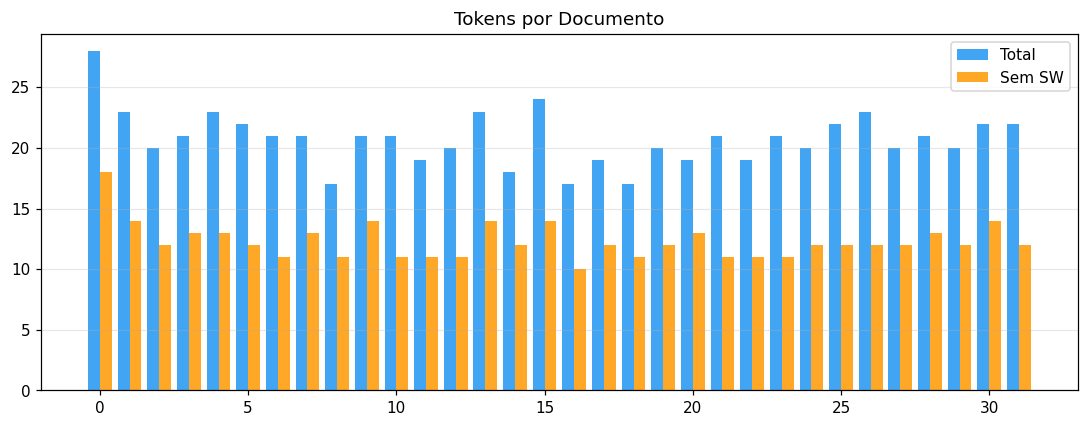

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(docs_proc))
ax.bar(x-0.2, tokens_list, 0.4, label='Total de Tokens', color='#2196F3', alpha=0.85)
ax.bar(x+0.2, sw_list,     0.4, label='Sem Stopwords',   color='#FF9800', alpha=0.85)
ax.set_title('Distribuição de Tokens por Documento')
ax.set_xlabel('Documento'); ax.set_ylabel('Tokens')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6 Boxplot

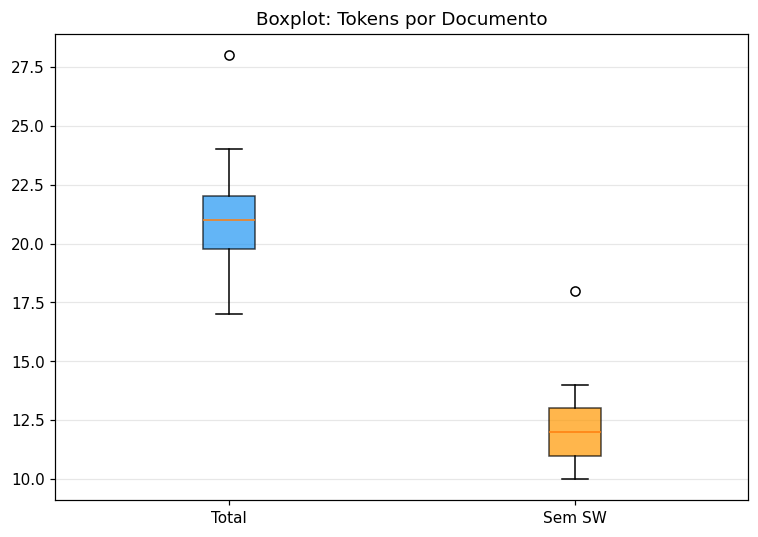

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
bp = ax.boxplot([tokens_list, sw_list], tick_labels=['Total','Sem SW'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#FF9800'); bp['boxes'][1].set_alpha(0.7)
ax.set_title('Boxplot: Tokens por Documento')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7 Top 20 Palavras Mais Frequentes

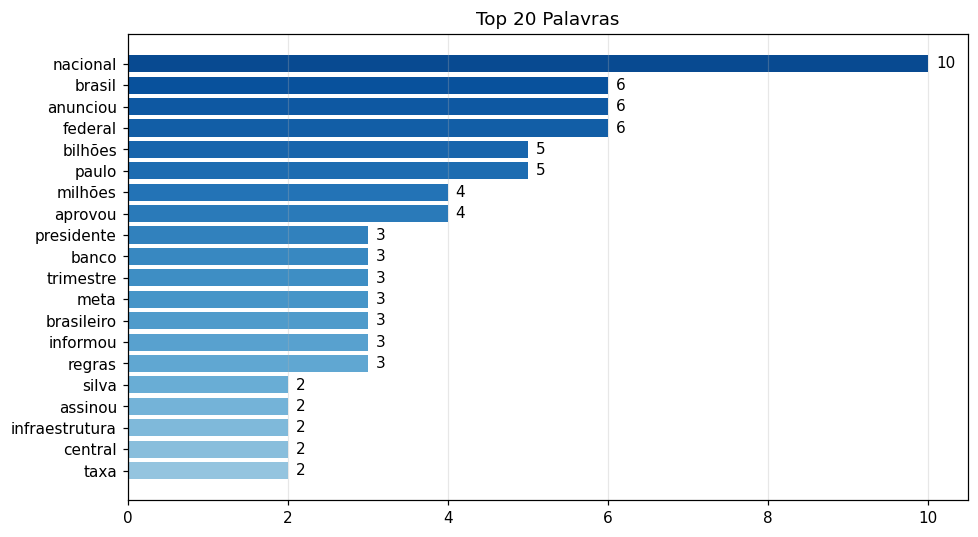

In [ ]:
from collections import Counter
all_tokens = [t for d in docs_proc for t in d['sem_sw']]
top_20 = Counter(all_tokens).most_common(20)
palavras = [p[0] for p in top_20]; freqs = [p[1] for p in top_20]

fig, ax = plt.subplots(figsize=(9,5))
colors_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(palavras)))[::-1]
bars = ax.barh(range(len(palavras)), freqs, color=colors_c)
ax.set_yticks(range(len(palavras))); ax.set_yticklabels(palavras, fontsize=10)
ax.invert_yaxis(); ax.set_title('Top 20 Palavras Mais Frequentes (sem Stopwords)')
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, str(freq), va='center')
ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

## 8 Salvamento

In [ ]:
import pandas as pd
df_stats = pd.DataFrame([{'id':d['id'],'n_tokens':len(d['tokens']),'n_tokens_sem_sw':len(d['sem_sw'])} for d in docs_proc])
df_stats.to_csv(DIRETORIO_LOCAL+'dataset_stats.csv', sep=';', index=False, encoding='utf-8')
print(f"dataset_stats.csv salvo! {len(df_stats)} documentos.")

dataset_stats.csv salvo! 32 documentos.


In [ ]:
import time,datetime
final=time.time()
print(f"Tempo: {str(datetime.timedelta(seconds=int(round(final-inicio_processamento))))} (h:mm:ss)")

Tempo: 0:00:06 (h:mm:ss)
